# Spiking neural network. Training

## Required libraries

In [24]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen
from snntorch import surrogate
from snntorch import utils
from snntorch import functional as SF

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools
import os
import shutil

## Data loading

In [25]:
# Dataloader arguments
batch_size = 128
data_path='/tmp/data/mnist'
sequence_len = 200

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)
# Create DataLoaders
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

train_loader_many = DataLoader(mnist_train, batch_size=1000, shuffle=True, drop_last=True)
test_loader_many = DataLoader(mnist_test, batch_size=1000, shuffle=True, drop_last=True)


## Additional functions

In [26]:

# this time, we won't return membrane as we don't need it
def forward_pass(net, data):
 spk_rec = []
 mem_rec = []
 utils.reset(net)  # resets hidden states for all LIF neurons in net

 for step in range(data.size(0)):  # data.size(0) = number of time steps
  spk_out, mem_out = net(data[step])
  spk_rec.append(spk_out)
  mem_rec.append(mem_out)

 return torch.stack(spk_rec)  # , torch.stack(mem_rec)


# this time, we return membrane
def forward_pass_with_mem(net, data):
 spk_rec = []
 mem_rec = []
 utils.reset(net)  # resets hidden states for all LIF neurons in net

 for step in range(data.size(0)):  # data.size(0) = number of time steps
  spk_out, mem_out = net(data[step])
  spk_rec.append(spk_out)
  mem_rec.append(mem_out)

 return torch.stack(spk_rec), torch.stack(mem_rec)

def calc_accuracy_for_all_data (net, train_loader_many, batch_len, sequence_len) :
    spk_rec_all = []
    training_acc = 0
    training_loss = 0
    k=0
    t = torch.empty(sequence_len, batch_len, 784)
    for i, (data, targets) in enumerate(iter(train_loader_many)):
        for ii in range(sequence_len):
            t[ii, :, :] = data.view(batch_len, -1)
        data = t.to(device)
        targets = targets.to(device)

        spk_rec = forward_pass(net, t)
        loss_val = loss_fn(spk_rec, targets).item()
        acc = SF.accuracy_rate(spk_rec, targets)
        training_acc += acc
        training_loss += loss_val
        k += 1
        #print(k, data.size())
    print(k)
    training_acc = training_acc / k
    training_loss = training_loss / k
    del data, targets, t

    return training_acc, training_loss


## Main parameters

In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# neuron and simulation parameters
spike_grad = surrogate.atan()
beta = 0.9
reset_mech = 'subtract'

num_epochs = 10
num_iters = 470
num_hidden_neurons = 100

net_no = 0 # can be any

## Define the network topology (choose the one of 3 variants)

### without filters

In [5]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, num_hidden_neurons, bias=False),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True),
                    nn.Linear(num_hidden_neurons, 10, bias=False),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True, output=True)
                    ).to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

### sigmoid

In [29]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, num_hidden_neurons, bias=False),
                    nn.Sigmoid(),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True),
                    nn.Linear(num_hidden_neurons, 10, bias=False),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True, output=True)
                    ).to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

### tanh

In [30]:
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, num_hidden_neurons, bias=False),
                    nn.Tanh(),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True),
                    nn.Linear(num_hidden_neurons, 10, bias=False),
                    snn.Leaky(beta=beta, threshold=1.0, spike_grad=spike_grad, reset_mechanism=reset_mech, init_hidden=True, output=True)
                    ).to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

## Training

In [30]:
loss_hist_iteration = []
acc_hist_iteration = []
acc_train_epoch = []
acc_test_epoch = []
loss_train_epoch = []
loss_test_epoch = []

# training loop
t = torch.empty(sequence_len, batch_size, 784)
for epoch in range(num_epochs):
 for i, (data, targets) in enumerate(iter(train_loader)):
  for ii in range(sequence_len):
   t[ii, :, :] = data.view(batch_size, -1)
  data = t.to(device)
  targets = targets.to(device)

  net.train()
  spk_rec = forward_pass(net, data)
  loss_val = loss_fn(spk_rec, targets)

  # Gradient calculation + weight update
  optimizer.zero_grad()
  loss_val.backward()
  optimizer.step()

  if i % 100 == 0: print(f"Epoch {epoch}, Iteration {i} \nTrain Loss: {loss_val.item():.2f}")

  acc = SF.accuracy_rate(spk_rec, targets)
  if i % 100 == 0: print(f"Accuracy: {acc * 100:.2f}%\n")


  acc_hist_iteration.append(acc)
  loss_hist_iteration.append(loss_val.item())

 acc_training, loss_training = calc_accuracy_for_all_data(net, train_loader_many, batch_len=1000, sequence_len=sequence_len)
 acc_testing, loss_testing = calc_accuracy_for_all_data(net, test_loader_many, batch_len=1000, sequence_len=sequence_len)
 print(acc_training, acc_testing, loss_training, loss_testing)

 acc_train_epoch.append(acc_training)
 acc_test_epoch.append(acc_testing)
 loss_train_epoch.append(loss_training)
 loss_test_epoch.append(loss_testing)

Epoch 0, Iteration 0 
Train Loss: 14.59
Accuracy: 14.06%

Epoch 0, Iteration 100 
Train Loss: 3.24
Accuracy: 84.38%

Epoch 0, Iteration 200 
Train Loss: 2.70
Accuracy: 89.06%

Epoch 0, Iteration 300 
Train Loss: 3.06
Accuracy: 82.81%

Epoch 0, Iteration 400 
Train Loss: 2.70
Accuracy: 86.72%

60
10
0.8688333333333332 0.8755000000000001 2.6555494626363116 2.6184040307998657
Epoch 1, Iteration 0 
Train Loss: 3.20
Accuracy: 83.59%

Epoch 1, Iteration 100 
Train Loss: 2.41
Accuracy: 88.28%

Epoch 1, Iteration 200 
Train Loss: 2.51
Accuracy: 91.41%

Epoch 1, Iteration 300 
Train Loss: 2.21
Accuracy: 89.84%

Epoch 1, Iteration 400 
Train Loss: 2.26
Accuracy: 88.28%

60
10
0.891466666666667 0.8971 2.170724042256673 2.1328784704208372
Epoch 2, Iteration 0 
Train Loss: 2.13
Accuracy: 89.06%

Epoch 2, Iteration 100 
Train Loss: 2.08
Accuracy: 90.62%

Epoch 2, Iteration 200 
Train Loss: 2.21
Accuracy: 85.94%

Epoch 2, Iteration 300 
Train Loss: 1.81
Accuracy: 90.62%

Epoch 2, Iteration 400 
Train

## Export trained network

60
10
Training acc.  0.9597333333333334
Testing acc.  0.9573
The data of trained network 0 were successfully written into last_net0


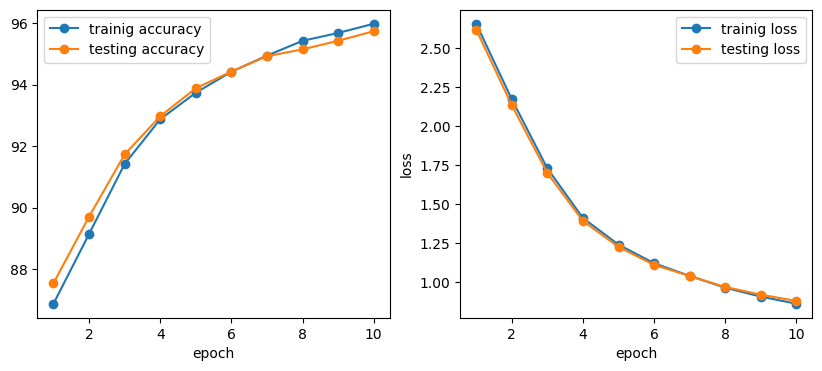

In [31]:
acc_training, loss_training = calc_accuracy_for_all_data(net, train_loader_many, batch_len=1000, sequence_len=sequence_len)
acc_testing, loss_testing = calc_accuracy_for_all_data(net, test_loader_many, batch_len=1000, sequence_len=sequence_len)
print("Training acc. ", acc_training)
print("Testing acc. ", acc_testing)

data_to_save = np.vstack((list(range(len(acc_train_epoch))), np.array(acc_train_epoch)*100, np.array(acc_test_epoch)*100, loss_train_epoch, loss_test_epoch)).T

folder_path = "last_net"
os.makedirs(folder_path, exist_ok=True)
torch.save(net.state_dict(), folder_path+'/topology')
np.savetxt(folder_path+"/training_accuracies_loss.txt", data_to_save, header='epoch | tr.acc. | te.acc. | tr.loss | te.loss', fmt='%.5f')

new_folder_path = folder_path + str(net_no)
if os.path.exists(new_folder_path): # Delete existing folder or file with the same name
    if os.path.isdir(new_folder_path): shutil.rmtree(new_folder_path)
    else: os.remove(new_folder_path)
    print(f"The existing folder '{new_folder_path}' has been deleted")
print("The data of trained network "+str(net_no)+ " were successfully written into "+new_folder_path)
os.rename(folder_path, new_folder_path)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(data_to_save[:,0]+1, data_to_save[:,1],'-o',label="trainig accuracy")
axs[0].plot(data_to_save[:,0]+1, data_to_save[:,2],'-o',label="testing accuracy")
axs[0].set_xlabel("accuracy")
axs[0].set_xlabel("epoch")
axs[0].legend()

axs[1].plot(data_to_save[:,0]+1, data_to_save[:,3],'-o',label="trainig loss")
axs[1].plot(data_to_save[:,0]+1, data_to_save[:,4],'-o',label="testing loss")
axs[1].set_ylabel("loss")
axs[1].set_xlabel("epoch")
axs[1].legend()